# DISCOVR EPIC L2

**The matchups in this notebook require xarray version > 2026.02**

The DSCOVR Earth Polychromatic Imaging Camera (EPIC) observes the sunlit Earth from the Sun–Earth L1 point and captures full-disk images of the planet in 10 UV–visible–near-IR spectral bands roughly every 1–2 hours.

Level-2 products are geophysical retrievals derived from EPIC radiances. 

* Cloud properties: cloud mask, cloud optical thickness, cloud effective pressure/height/temperature, cloud phase
* Aerosols: aerosol optical depth, aerosol index
* Trace gases: total column ozone, sulfur dioxide (SO₂)
* Surface/vegetation: surface reflectivity, UV aerosol index, vegetation indices (e.g., NDVI)

This notebook will use two DISCOVR EPIC Level 2 products.

* DSCOVR_EPIC_L2_AER, Version 03, aerosols
* DSCOVR_EPIC_L2_TO3 Version 03, total column ozone (TO₃)

These granules are big and the grid is not reqular. A KD tree is used for level 2 data and this can be slow.

*Note: In a virtual machine in AWS us-west-2, where NASA cloud data is, the point matchups are faster. In Colab, say, your compute is not in the same data region nor provider, and the same matchups might take 10x longer.*

## Prerequisites

The examples here use NASA EarthData and you need to have an account with EarthData. Make sure you can login.

In [2]:
# if needed
!pip install point-collocation cartopy "xarray>=2026.2" --quiet

In [2]:
import earthaccess
earthaccess.login()

#### Check the xarray version

In [3]:
import xarray as xr
xr.__version__

'2026.2.0'

## DSCOVR_EPIC_L2_AER

### Create some points

Random global and in 2024.

In [1]:
import pandas as pd
url = (
    "https://raw.githubusercontent.com/"
    "fish-pace/point-collocation/main/"
    "examples/fixtures/points_1000.csv"
)
df_points = pd.read_csv(
    url,
    parse_dates=["time"]
)
df = df_points[
    (df_points["time"].dt.year == 2024)
]
print(len(df))
df.head()

31


,lat,lon,time,land
35,9.100711,11.216734,2024-07-21,True
43,-67.209878,-62.734423,2024-04-16,False
83,87.228338,-29.718344,2024-10-13,False
190,34.701655,-20.040258,2024-04-21,False
222,-8.043907,41.779801,2024-08-31,False


### Create the plan

We look for granules within 1 hour of our points. There are 14 points that have matches and some have multiple matches (granules).

In [2]:
%%time
import point_collocation as pc
short_name="DSCOVR_EPIC_L2_AER"
plan = pc.plan(
    df,
    data_source="earthaccess",
    source_kwargs={
        "short_name": short_name,
        "version": "03"
    },
    time_buffer="1h"
)

CPU times: user 1.55 s, sys: 136 ms, total: 1.68 s
Wall time: 7.36 s


In [13]:
plan.summary(n=0)

Plan: 31 points → 17 unique granule(s)
  Points with 0 matches : 20
  Points with >1 matches: 6
  Time buffer: 0 days 01:00:00


### Look at the variables

We will open a file with datatree and see what groups it has.

In [5]:
ds = plan.open_dataset(1, open_method="datatree")
ds

open_method: {'xarray_open': 'datatree', 'open_kwargs': {'chunks': {}, 'engine': 'h5netcdf', 'decode_timedelta': False}, 'merge': None, 'coords': 'auto', 'set_coords': True, 'dim_renames': None, 'auto_align_phony_dims': None}


<xarray.DataTree>
Group: /
├── Group: /HDFEOS
│   ├── Group: /HDFEOS/ADDITIONAL
│   │   └── Group: /HDFEOS/ADDITIONAL/FILE_ATTRIBUTES
│   │           Attributes: (12/22)
│   │               ACF Filename:        acf_epic_sm_ffxt_aug2019.txt
│   │               AIRSCO_filename1:    AIRS.2016.05.08.L3.RetStd_IR001.v6.0.31.0.G161301816...
│   │               AIRSCO_filename2:    AIRS.2016.05.07.L3.RetStd_IR001.v6.0.31.0.G161291747...
│   │               AuthorAffiliation:   NASA/GSFC
│   │               AuthorName:          Omar Torres
│   │               EarthSunDistance:    0.9862366
│   │               ...                  ...
│   │               ProcessingCenter:    TLCF                                                ...
│   │               ProcessingHost:      Linux ominate.gsfc.nasa.gov 2.6.18-410.el5PAE #1 SMP...
│   │               ProductionDateTime:  2024-02-11T01:29:46.0Z
│   │               ShortName:           EPICAERUV
│   │               Time_Band340nm:      2024-02-08 01:57:26
│   │               Time_Band388nm:      2024-02-08 01:56:59
│   └── Group: /HDFEOS/SWATHS
│       └── Group: /HDFEOS/SWATHS/Aerosol NearUV Swath
│           ├── Group: /HDFEOS/SWATHS/Aerosol NearUV Swath/Data Fields
│           │       Dimensions:                         (phony_dim_0: 2048, phony_dim_1: 2048,
│           │                                            phony_dim_2: 5, phony_dim_3: 3,
│           │                                            phony_dim_4: 2)
│           │       Dimensions without coordinates: phony_dim_0, phony_dim_1, phony_dim_2,
│           │                                       phony_dim_3, phony_dim_4
│           │       Data variables: (12/29)
│           │           AIRSCO_Flags                    (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
│           │           AIRSL3COvalue                   (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
│           │           AerosolAbsOpticalDepthVsHeight  (phony_dim_0, phony_dim_1, phony_dim_2, phony_dim_3) float32 252MB dask.array<chunksize=(256, 1024, 5, 3), meta=np.ndarray>
│           │           AerosolCorrCloudOpticalDepth    (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
│           │           AerosolOpticalDepthOverCloud    (phony_dim_0, phony_dim_1, phony_dim_3) float32 50MB dask.array<chunksize=(256, 1024, 2), meta=np.ndarray>
│           │           AerosolOpticalDepthVsHeight     (phony_dim_0, phony_dim_1, phony_dim_2, phony_dim_3) float32 252MB dask.array<chunksize=(256, 1024, 5, 3), meta=np.ndarray>
│           │           ...                              ...
│           │           Reflectivity                    (phony_dim_0, phony_dim_1, phony_dim_4) float32 34MB dask.array<chunksize=(256, 1024, 2), meta=np.ndarray>
│           │           Residue                         (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
│           │           SurfaceAlbedo                   (phony_dim_0, phony_dim_1, phony_dim_4) float32 34MB dask.array<chunksize=(256, 1024, 2), meta=np.ndarray>
│           │           SurfaceType                     (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
│           │           UVAerosolIndex                  (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
│           │           Wavelength                      (phony_dim_3) float32 12B dask.array<chunksize=(3,), meta=np.ndarray>
│           └── Group: /HDFEOS/SWATHS/Aerosol NearUV Swath/Geolocation Fields
│                   Dimensions:               (phony_dim_5: 2048, phony_dim_6: 2048)
│                   Dimensions without coordinates: phony_dim_5, phony_dim_6
│                   Data variables:
│                       Latitude              (phony_dim_5, phony_dim_6) float32 17MB dask.array<chunksize=(256, 102

The data are in `/HDFEOS/SWATHS/Aerosol NearUV Swath/Data Fields` and lat/lon are in `/HDFEOS/SWATHS/Aerosol NearUV Swath/Geolocation Fields`. We create a profile. We open a dataset with the profile to make sure it looks good.

In [4]:
%%time
discovr_epic_aer = {
    'xarray_open': 'dataset',
    'merge': ['/HDFEOS/SWATHS/Aerosol NearUV Swath/Geolocation Fields', '/HDFEOS/SWATHS/Aerosol NearUV Swath/Data Fields'],
    'open_kwargs': {'phony_dims':'access'}
}
ds = plan.open_dataset(1, open_method=discovr_epic_aer)
ds

open_method: {'xarray_open': 'dataset', 'merge': ['/HDFEOS/SWATHS/Aerosol NearUV Swath/Geolocation Fields', '/HDFEOS/SWATHS/Aerosol NearUV Swath/Data Fields'], 'open_kwargs': {'phony_dims': 'access', 'chunks': {}, 'engine': 'h5netcdf', 'decode_timedelta': False}, 'coords': 'auto', 'set_coords': True, 'dim_renames': None, 'auto_align_phony_dims': None, 'merge_kwargs': {}}
CPU times: user 803 ms, sys: 99.6 ms, total: 903 ms
Wall time: 4.35 s


<xarray.Dataset> Size: 2GB
Dimensions:                         (phony_dim_0: 2048, phony_dim_1: 2048,
                                     phony_dim_2: 5, phony_dim_3: 3,
                                     phony_dim_4: 2)
Coordinates:
    Latitude                        (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
    Longitude                       (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
Dimensions without coordinates: phony_dim_0, phony_dim_1, phony_dim_2,
                                phony_dim_3, phony_dim_4
Data variables: (12/34)
    RelativeAzimuthAngle            (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
    SnowIce_fraction                (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
    SolarZenithAngle                (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
    TerrainPressure                 (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
    ViewingZenithAngle              (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
    AIRSCO_Flags                    (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
    ...                              ...
    Reflectivity                    (phony_dim_0, phony_dim_1, phony_dim_4) float32 34MB dask.array<chunksize=(256, 1024, 2), meta=np.ndarray>
    Residue                         (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
    SurfaceAlbedo                   (phony_dim_0, phony_dim_1, phony_dim_4) float32 34MB dask.array<chunksize=(256, 1024, 2), meta=np.ndarray>
    SurfaceType                     (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
    UVAerosolIndex                  (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
    Wavelength                      (phony_dim_3) float32 12B dask.array<chunksize=(3,), meta=np.ndarray>

## Let's get the matchups

In [15]:
%%time
res = pc.matchup(plan[0:10], 
                 variables = ["UVAerosolIndex"], 
                 open_method=discovr_epic_aer)

CPU times: user 49.5 s, sys: 497 ms, total: 50 s
Wall time: 1min 11s


In [11]:
# full res shows more info about matchups, like the granule lat lon
var = 'UVAerosolIndex'
res[['lat', 'lon', 'time', 'pc_id', var]].dropna(subset=[var]).head()

,lat,lon,time,pc_id,UVAerosolIndex
5,6.631233,-138.494233,2024-05-08,245,1.105056
6,-20.064168,-173.807753,2024-02-16,273,0.151248
8,34.247526,-166.904639,2024-08-21,342,0.469726
9,34.247526,-166.904639,2024-08-21,342,0.536712


This takes about 25 seconds per point/granule. We will want to use parallel processing to speed this up so we can make many granule I/O requests at once.

## Let's make a plot

We could do `ds.UVAerosolIndex.plot(robust=True)` which is fast but also ugly plot. The following makes a prettier plot.

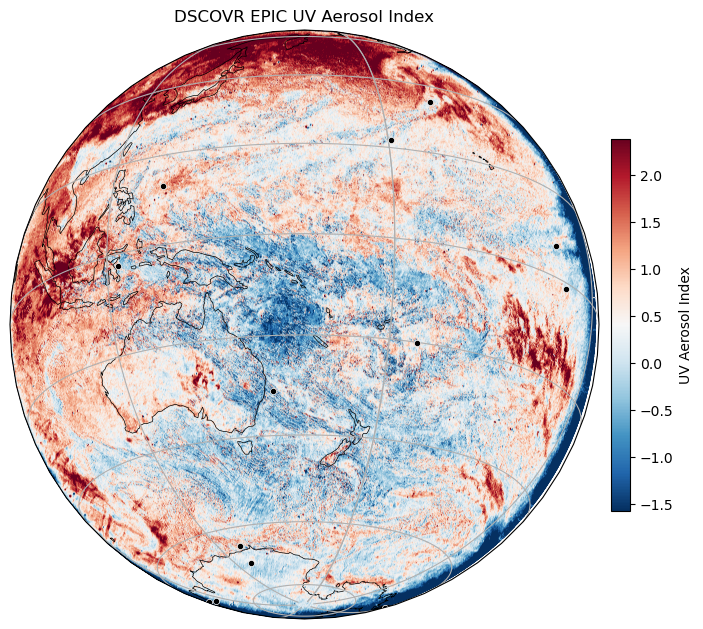

In [11]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import numpy as np

# mask fill values
fill = ds.UVAerosolIndex.attrs["MissingValue"]
uvai = ds.UVAerosolIndex.where(ds.UVAerosolIndex != fill)

lat = ds.Latitude.values
lon = ds.Longitude.values
val = uvai.values
vmin, vmax = np.nanpercentile(val, [2, 98])

# flatten for scatter
lat = lat.flatten()
lon = lon.flatten()
val = val.flatten()

# projection center (mean location of valid pixels)
lat2d = ds.Latitude.values
lon2d = ds.Longitude.values

iy = lat2d.shape[0] // 2
ix = lat2d.shape[1] // 2

lat_m = float(lat2d[iy, ix])
lon_m = float(lon2d[iy, ix])

proj = ccrs.Orthographic(central_longitude=lon_m, central_latitude=lat_m)

fig = plt.figure(figsize=(8,8))
ax = plt.axes(projection=proj)

# coastlines
ax.coastlines(linewidth=0.5)

# gridlines
grid = ax.gridlines(draw_labels=False)
grid.xformatter = LONGITUDE_FORMATTER
grid.yformatter = LATITUDE_FORMATTER

# plot swath
im = ax.scatter(
    lon,
    lat,
    c=val,
    s=1,
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    transform=ccrs.PlateCarree()
)

# points
ax.scatter(
    df["lon"],
    df["lat"],
    color="black",
    s=20,
    edgecolor="white",
    linewidth=0.5,
    transform=ccrs.PlateCarree(),
    zorder=10
)

plt.colorbar(im, fraction=0.03, pad=0.02, label="UV Aerosol Index")

plt.title("DSCOVR EPIC UV Aerosol Index")
plt.show()

## DSCOVR_EPIC_L2_TO3

Total ozone.

In [18]:
%%time
import point_collocation as pc
short_name="DSCOVR_EPIC_L2_TO3"
plan = pc.plan(
    df,
    data_source="earthaccess",
    source_kwargs={
        "short_name": short_name,
        "version": "03"
    },
    time_buffer="1h"
)

CPU times: user 816 ms, sys: 69.6 ms, total: 886 ms
Wall time: 11.9 s


### Look at variables

All the data is in the base group so we do not need to pass in `open_method`; the default `open_dataset` will work fine. Our variable of interest is "Ozone".

In [22]:
ds = plan.open_dataset(1, open_method="dataset")
ds

open_method: {'xarray_open': 'dataset', 'open_kwargs': {'chunks': {}, 'engine': 'h5netcdf', 'decode_timedelta': False}, 'merge': None, 'coords': 'auto', 'set_coords': True, 'dim_renames': None, 'auto_align_phony_dims': None}


<xarray.Dataset> Size: 549MB
Dimensions:                      (phony_dim_0: 2048, phony_dim_1: 2048,
                                  phony_dim_2: 4, phony_dim_3: 11,
                                  phony_dim_4: 26, phony_dim_5: 3,
                                  phony_dim_6: 1, phony_dim_7: 8)
Coordinates:
    Latitude                     (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 256), meta=np.ndarray>
    Longitude                    (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 256), meta=np.ndarray>
Dimensions without coordinates: phony_dim_0, phony_dim_1, phony_dim_2,
                                phony_dim_3, phony_dim_4, phony_dim_5,
                                phony_dim_6, phony_dim_7
Data variables: (12/27)
    AlgorithmFlag                (phony_dim_0, phony_dim_1) int16 8MB dask.array<chunksize=(256, 256), meta=np.ndarray>
    CalibrationCoef              (phony_dim_2) float32 16B dask.array<chunksize=(4,), meta=np.ndarray>
    CloudPressure                (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 256), meta=np.ndarray>
    ColumnWeightFunctionPercent  (phony_dim_0, phony_dim_1, phony_dim_3) uint8 46MB dask.array<chunksize=(256, 256, 11), meta=np.ndarray>
    ControlFileContents          (phony_dim_4) object 208B dask.array<chunksize=(26,), meta=np.ndarray>
    DNDomega                     (phony_dim_0, phony_dim_1, phony_dim_5) float32 50MB dask.array<chunksize=(256, 256, 3), meta=np.ndarray>
    ...                           ...
    SlopeOfReflectivity          (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 256), meta=np.ndarray>
    SolarAzimuthAngle            (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 256), meta=np.ndarray>
    SolarZenithAngle             (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 256), meta=np.ndarray>
    TerrainPressure              (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 256), meta=np.ndarray>
    Wavelength                   (phony_dim_2) float32 16B dask.array<chunksize=(4,), meta=np.ndarray>
    YearDaySeconds               (phony_dim_5) int32 12B dask.array<chunksize=(3,), meta=np.ndarray>

In [23]:
%%time
res = pc.matchup(plan[0:10], variables = ["Ozone"])

CPU times: user 35.8 s, sys: 942 ms, total: 36.8 s
Wall time: 1min 34s


In [24]:
var = 'Ozone'
res[['lat', 'lon', 'time', 'pc_id', var]].dropna(subset=[var]).head()

,lat,lon,time,pc_id,Ozone
5,6.631233,-138.494233,2024-05-08,245,249.927444
6,-20.064168,-173.807753,2024-02-16,273,233.636459
8,34.247526,-166.904639,2024-08-21,342,316.187988
9,34.247526,-166.904639,2024-08-21,342,314.785095


## Make a plot

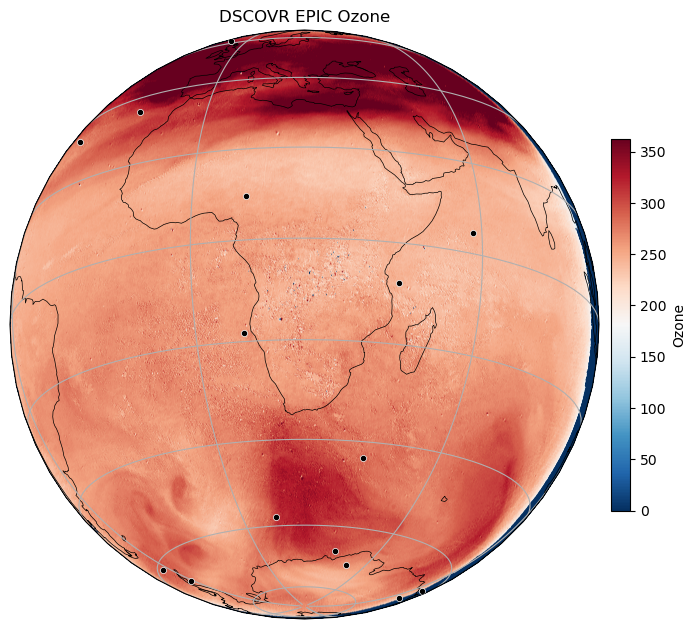

In [30]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import numpy as np

var = 'Ozone'
uvai = ds[var]

lat = ds.Latitude.values
lon = ds.Longitude.values
val = uvai.values
vmin, vmax = np.nanpercentile(val, [2, 98])
vmin=0

# flatten for scatter
lat = lat.flatten()
lon = lon.flatten()
val = val.flatten()

# projection center (mean location of valid pixels)
lat2d = ds.Latitude.values
lon2d = ds.Longitude.values

iy = lat2d.shape[0] // 2
ix = lat2d.shape[1] // 2

lat_m = float(lat2d[iy, ix])
lon_m = float(lon2d[iy, ix])

proj = ccrs.Orthographic(central_longitude=lon_m, central_latitude=lat_m)

fig = plt.figure(figsize=(8,8))
ax = plt.axes(projection=proj)

# coastlines
ax.coastlines(linewidth=0.5)

# gridlines
grid = ax.gridlines(draw_labels=False)
grid.xformatter = LONGITUDE_FORMATTER
grid.yformatter = LATITUDE_FORMATTER

# plot swath
im = ax.scatter(
    lon,
    lat,
    c=val,
    s=1,
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    transform=ccrs.PlateCarree()
)

# points
ax.scatter(
    df["lon"],
    df["lat"],
    color="black",
    s=20,
    edgecolor="white",
    linewidth=0.5,
    transform=ccrs.PlateCarree(),
    zorder=10
)

plt.colorbar(im, fraction=0.03, pad=0.02, label="Ozone")

plt.title("DSCOVR EPIC Ozone")
plt.show()